In [1]:
!pip install yfinance pandas streamlit sqlalchemy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 80.5 MB/s eta 0:00:00


In [2]:
import yfinance as yf
import pandas as pd

# Indian stocks on NSE
stocks = ['RELIANCE.NS', 'TCS.NS', 'INFY.NS', 'HDFCBANK.NS', 'WIPRO.NS']

# Fetch last 1 month data
data = yf.download(stocks, period='1mo', interval='1d')

# Show closing prices
print(data['Close'])

/tmp/ipykernel_1390/414995724.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stocks, period='1mo', interval='1d')
[*********************100%***********************]  5 of 5 completed


Ticker      HDFCBANK.NS      INFY.NS  RELIANCE.NS       TCS.NS    WIPRO.NS
Date                                                                      
2026-02-24   910.500000  1275.500000  1428.800049  2573.699951  200.139999
2026-02-25   907.599976  1290.099976  1398.500000  2629.300049  201.919998
2026-02-26   898.599976  1289.099976  1406.800049  2647.699951  201.080002
2026-02-27   887.750000  1300.099976  1393.900024  2637.399902  200.960007
2026-03-02   879.400024  1288.900024  1358.000000  2613.500000  198.570007
2026-03-04   868.650024  1307.400024  1345.000000  2587.800049  195.550003
2026-03-05   877.750000  1305.800049  1389.400024  2578.800049  195.679993
2026-03-06   857.049988  1308.400024  1404.800049  2557.600098  195.399994
2026-03-09   840.700012  1315.000000  1424.000000  2527.399902  198.750000
2026-03-10   849.450012  1295.599976  1408.800049  2513.100098  200.929993
2026-03-11   833.950012  1276.300049  1390.199951  2464.899902  202.229996
2026-03-12   832.750000  

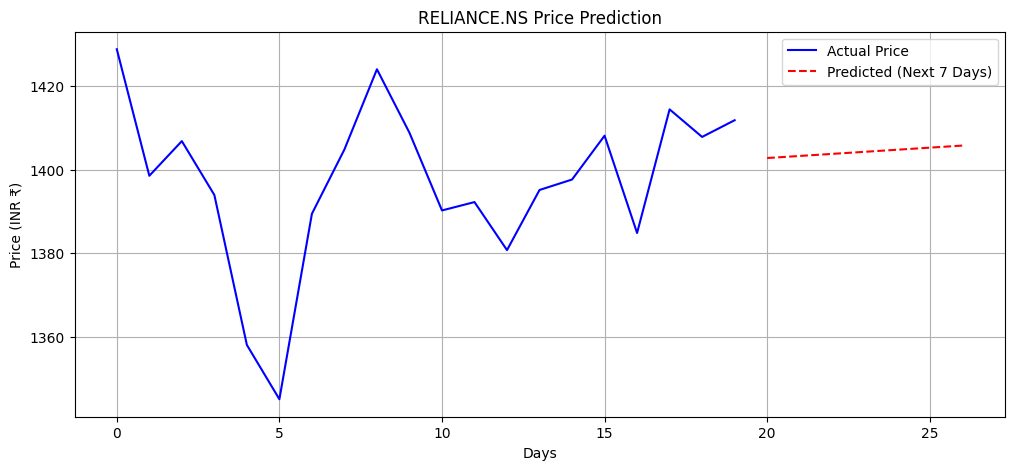


📈 RELIANCE.NS Next 7 Days Prediction:
  Day 1: ₹1402.75
  Day 2: ₹1403.24
  Day 3: ₹1403.74
  Day 4: ₹1404.24
  Day 5: ₹1404.73
  Day 6: ₹1405.23
  Day 7: ₹1405.73


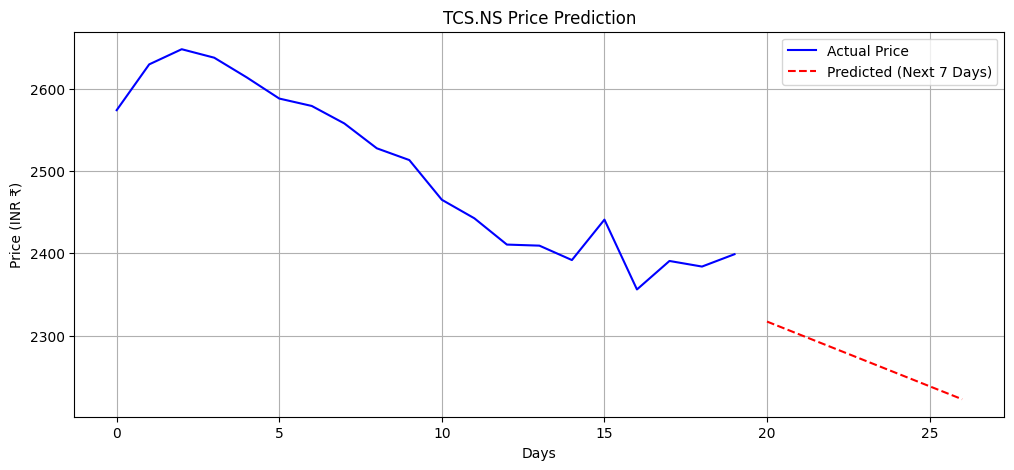


📈 TCS.NS Next 7 Days Prediction:
  Day 1: ₹2317.02
  Day 2: ₹2301.30
  Day 3: ₹2285.59
  Day 4: ₹2269.87
  Day 5: ₹2254.16
  Day 6: ₹2238.44
  Day 7: ₹2222.73


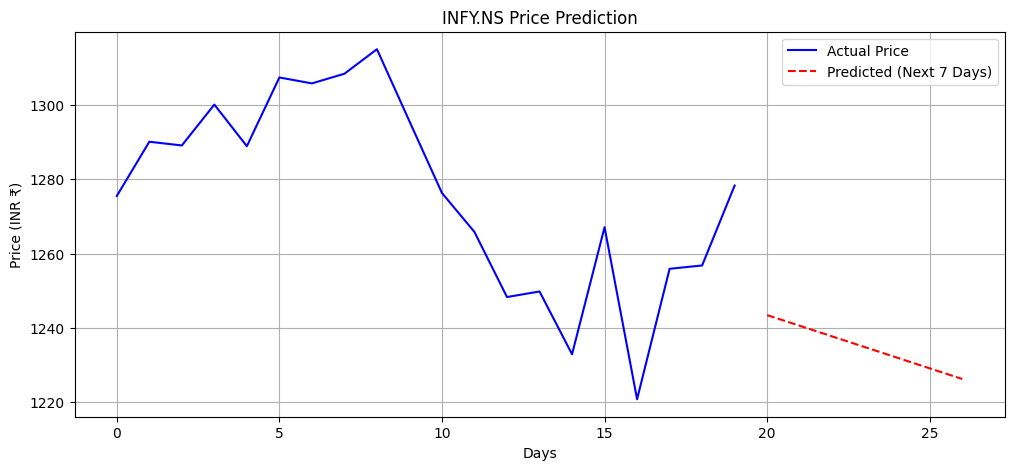


📈 INFY.NS Next 7 Days Prediction:
  Day 1: ₹1243.44
  Day 2: ₹1240.57
  Day 3: ₹1237.71
  Day 4: ₹1234.84
  Day 5: ₹1231.98
  Day 6: ₹1229.11
  Day 7: ₹1226.24


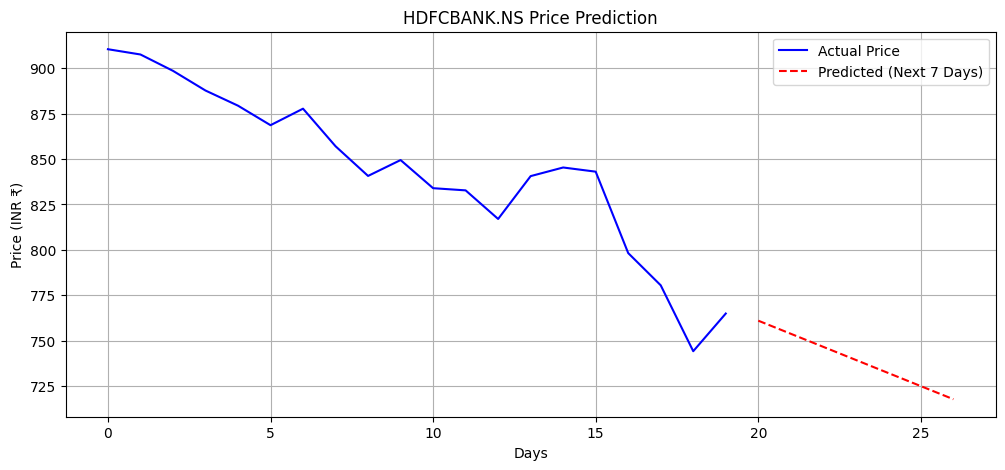


📈 HDFCBANK.NS Next 7 Days Prediction:
  Day 1: ₹760.97
  Day 2: ₹753.75
  Day 3: ₹746.54
  Day 4: ₹739.33
  Day 5: ₹732.12
  Day 6: ₹724.91
  Day 7: ₹717.70


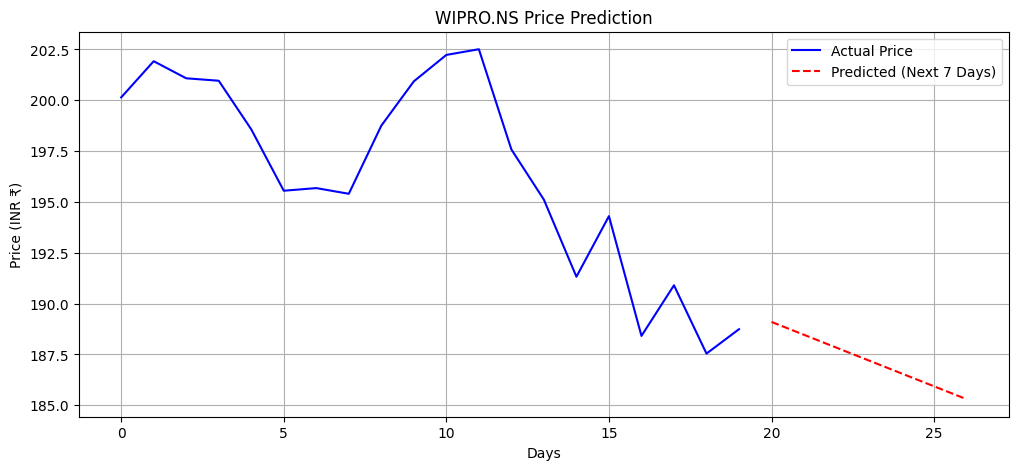


📈 WIPRO.NS Next 7 Days Prediction:
  Day 1: ₹189.10
  Day 2: ₹188.46
  Day 3: ₹187.83
  Day 4: ₹187.20
  Day 5: ₹186.56
  Day 6: ₹185.93
  Day 7: ₹185.30


In [8]:
#Price Prediction
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Define close_prices from the 'data' DataFrame, resetting the index to make 'Date' a column
close_prices = data['Close'].reset_index()
close_prices = close_prices.rename(columns={'index': 'Date'})

def predict_stock(stock_name):

# Step 1 - Get single stock prices
    stock_data = close_prices[['Date', stock_name]].copy()
    stock_data['Days'] = range(len(stock_data))
# Step 2 - Prepare data for ML
    X = stock_data[['Days']]
    y = stock_data[stock_name]
# Step 3 - Train the model
    model = LinearRegression()
    model.fit(X, y)
# Step 4 - Predict next 7 days
    last_day = len(stock_data)
    # Create a DataFrame for future days with the same column name 'Days'
    future_days_df = pd.DataFrame([[last_day + i] for i in range(1, 8)], columns=['Days'])
    predictions = model.predict(future_days_df)
# Step 5 - Plot results
    plt.figure(figsize=(12, 5))
    plt.plot(stock_data['Days'],
             stock_data[stock_name],
             label='Actual Price',
             color='blue')
    plt.plot(range(last_day, last_day + 7),
             predictions,
             label='Predicted (Next 7 Days)',
             color='red',
             linestyle='--')
    plt.title(f'{stock_name} Price Prediction')
    plt.xlabel('Days')
    plt.ylabel('Price (INR ₹)')
    plt.legend()
    plt.grid(True)
    plt.show()

 # Step 6 - Print predictions
    print(f"\n📈 {stock_name} Next 7 Days Prediction:")
    for i, price in enumerate(predictions, 1):
        print(f"  Day {i}: ₹{price:.2f}")

# Run prediction for all stocks
for stock in stocks:
    predict_stock(stock)